## Data Loading and Inspection

In [12]:
%cd /content

/content


In [13]:
!mkdir -p ml-assessment-shantanu-rastogi/part_a
!mkdir -p ml-assessment-shantanu-rastogi/part_b
!mkdir -p ml-assessment-shantanu-rastogi/data

In [14]:
%cd ml-assessment-shantanu-rastogi/part_a

/content/ml-assessment-shantanu-rastogi/part_a


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv('../data/q1_heart_disease.csv')

In [19]:
df = pd.read_csv('../data/q1_heart_disease.csv')
df.head()

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


## Exploratory Data Analysis

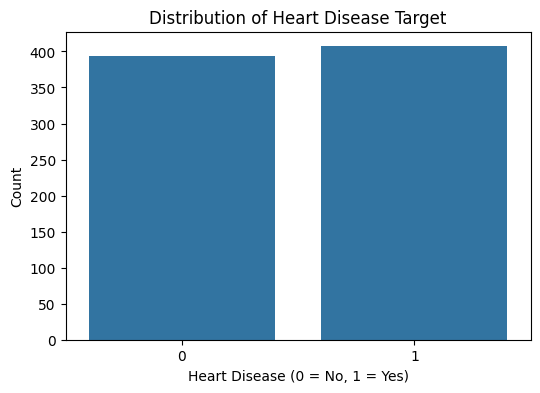

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x='heart_disease', data=df)

plt.title('Distribution of Heart Disease Target')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')

plt.show()

### Interpretation: Target Class Distribution

The target classes appear fairly balanced, with similar numbers of patients with and without heart disease.

- This is a good sign because severe class imbalance does not appear to be a major concern.
- A balanced target distribution helps classification models learn both classes more effectively.

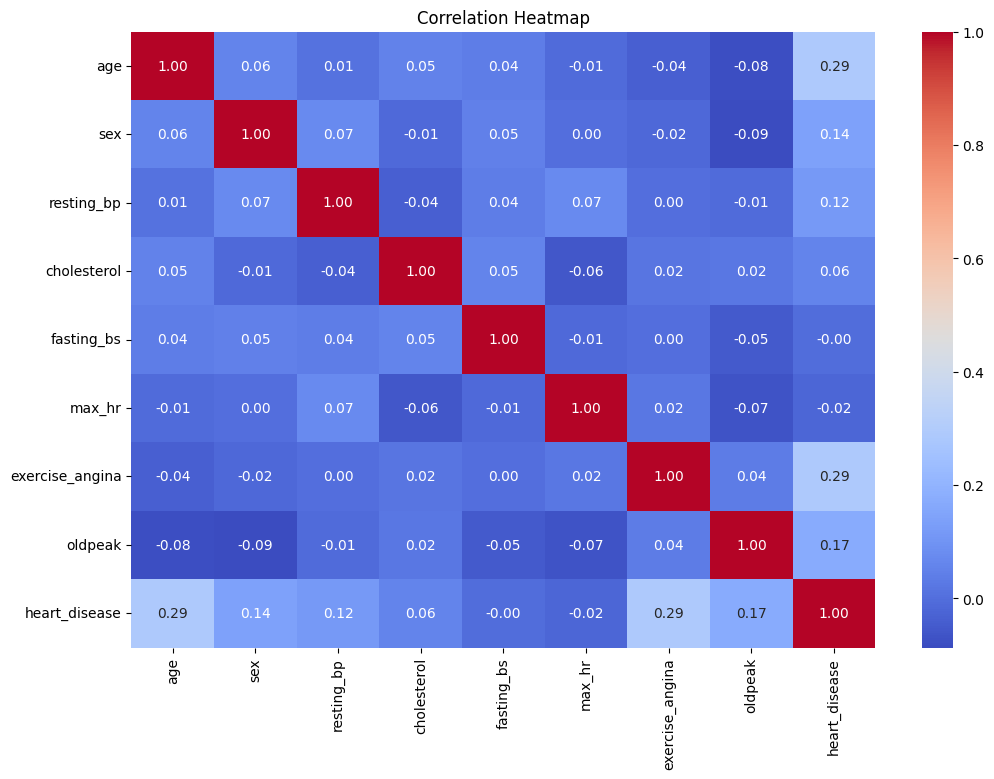

In [21]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

### Interpretation: Correlation Heatmap

The heatmap shows that age and exercise_angina have relatively stronger positive relationships with heart_disease compared to other numerical variables.

- This suggests these features may be important predictors.
- Most variables do not show extremely high correlation with one another, which suggests severe multicollinearity may not be a major issue.
- These relationships can help guide model training and feature importance analysis later.

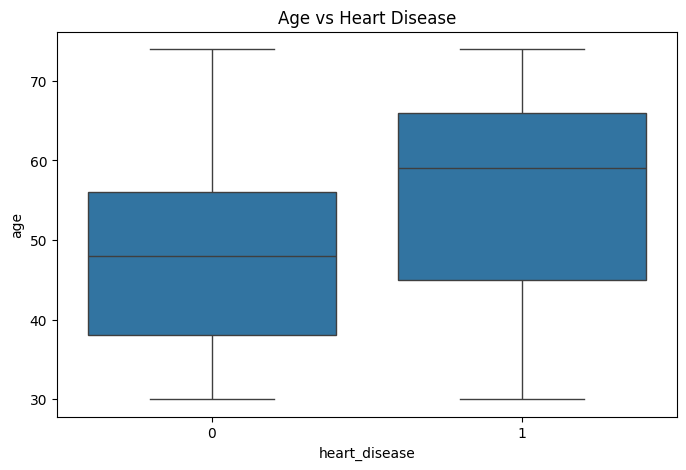

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='heart_disease',
    y='age',
    data=df
)

plt.title('Age vs Heart Disease')

plt.show()

### Interpretation: Age vs Heart Disease

The boxplot suggests patients with heart disease tend to have a higher median age compared to patients without heart disease.

- This indicates age may be an important predictor.
- Older individuals may show greater likelihood of heart disease in this dataset.
- This supports including age as a potentially influential feature during modeling.

## Data Preprocessing

In [23]:
df.isnull().sum()

,0
age,0
sex,0
chest_pain_type,0
resting_bp,24
cholesterol,32
fasting_bs,0
resting_ecg,0
max_hr,0
exercise_angina,0
oldpeak,0


### Missing Value Strategy

Missing values are checked before modeling.

For numerical features, median imputation will be used if missing values are present because:

- Median is robust to outliers
- It preserves the general distribution better than mean imputation

In [24]:
# Fill missing values in numerical columns using median

for col in df.select_dtypes(include=['number']).columns:
    df[col] = df[col].fillna(df[col].median())

In [25]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,age,sex,resting_bp,cholesterol,fasting_bs,max_hr,exercise_angina,oldpeak,heart_disease,chest_pain_type_atypical_angina,chest_pain_type_non_anginal,chest_pain_type_typical_angina,resting_ecg_normal,resting_ecg_st_t_wave_abnormality,st_slope_flat,st_slope_up
0,68,0,142.0,399.0,0,169,0,0.4,1,True,False,False,False,False,False,True
1,58,1,163.0,310.0,1,121,1,1.1,1,False,True,False,False,True,False,True
2,44,1,128.0,175.0,0,183,1,0.2,0,False,True,False,True,False,False,True
3,72,1,114.0,177.0,0,150,0,1.0,1,False,False,False,False,True,False,True
4,37,1,149.0,271.0,0,136,0,0.4,0,False,True,False,True,False,True,False


### Encoding Categorical Variables

Categorical features were converted into numerical form using one-hot encoding.

This is necessary because machine learning models cannot directly process text-based categories.

In [26]:
X = df_encoded.drop('heart_disease', axis=1)
y = df_encoded['heart_disease']

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

### Train-Test Split

The data was split into:

- 80% training data
- 20% testing data

Stratification was used to preserve the target class distribution in both sets.

In [30]:
from sklearn.preprocessing import StandardScaler

In [31]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [32]:
print(X_train_scaled[:5])

[[ 0.85247313  0.71624183  0.72223487  1.0505499  -0.55328334  0.59544279
  -0.64978629 -0.15025633 -0.47545099  1.6897993  -0.2847474   1.015749
  -0.76944123 -0.71374643  1.05461425]
 [-1.02077255 -1.39617648  1.41884172 -0.42467232 -0.55328334  2.38519686
   1.53896753  0.1757235  -0.47545099 -0.59178625 -0.2847474   1.015749
  -0.76944123 -0.71374643 -0.948214  ]
 [ 1.55494026  0.71624183 -1.05094623 -1.35639161 -0.55328334  0.05851657
  -0.64978629  0.06706356 -0.47545099 -0.59178625 -0.2847474  -0.98449518
   1.29964442 -0.71374643  1.05461425]
 [-0.08414971  0.71624183  0.65890697 -1.33698079 -0.55328334 -0.47840965
  -0.64978629  0.1757235  -0.47545099 -0.59178625 -0.2847474   1.015749
  -0.76944123  1.4010578  -0.948214  ]
 [-0.55246113 -1.39617648 -1.11427412 -0.63819132 -0.55328334  1.89301449
  -0.64978629  0.06706356 -0.47545099 -0.59178625  3.51188458 -0.98449518
   1.29964442 -0.71374643  1.05461425]]


### Feature Scaling

Numerical features were standardized using StandardScaler.

Scaling helps improve model performance when variables exist on different ranges and ensures fair contribution of features during training.

## Model Training

In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [34]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train_scaled, y_train)

DecisionTreeClassifier(random_state=42)

In [35]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [36]:
gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train_scaled, y_train)

GradientBoostingClassifier(random_state=42)

### Model Training

Three classification models were trained:

- Decision Tree
- Random Forest
- Gradient Boosting

These models will be evaluated next to determine which performs best.

In [37]:
print("All models trained successfully.")

All models trained successfully.


## Model Evaluation

In [38]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [39]:
dt_pred = dt_model.predict(X_test_scaled)

print("Decision Tree Confusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

print("\nDecision Tree Classification Report:")
print(classification_report(y_test, dt_pred))

Decision Tree Confusion Matrix:
[[57 22]
 [25 56]]

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.72      0.71        79
           1       0.72      0.69      0.70        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160



In [40]:
rf_pred = rf_model.predict(X_test_scaled)

print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Confusion Matrix:
[[61 18]
 [15 66]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160



In [41]:
gb_pred = gb_model.predict(X_test_scaled)

print("Gradient Boosting Confusion Matrix:")
print(confusion_matrix(y_test, gb_pred))

print("\nGradient Boosting Classification Report:")
print(classification_report(y_test, gb_pred))

Gradient Boosting Confusion Matrix:
[[61 18]
 [19 62]]

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
           1       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



### Best Performing Model

Based on the evaluation metrics, the Random Forest Classifier performed best.

Reasons:

- It achieved the highest accuracy (0.79)
- It produced the highest F1-score (0.79)
- It showed a strong balance between precision and recall

Compared to Decision Tree and Gradient Boosting, Random Forest provided the most reliable classification performance on the test set.

Therefore, Random Forest is selected as the best-performing model.

## Hyperparameter Tuning

In [42]:
from sklearn.model_selection import GridSearchCV

In [43]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10]
}

In [44]:
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1'
)

grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [None, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='f1')

In [45]:
print("Best Parameters Found:")
print(grid_search.best_params_)

Best Parameters Found:
{'max_depth': None, 'n_estimators': 200}


In [46]:
best_rf = grid_search.best_estimator_

tuned_pred = best_rf.predict(X_test_scaled)

print(confusion_matrix(y_test, tuned_pred))

print(classification_report(y_test, tuned_pred))

[[59 20]
 [17 64]]
              precision    recall  f1-score   support

           0       0.78      0.75      0.76        79
           1       0.76      0.79      0.78        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



### Hyperparameter Tuning

GridSearchCV identified the best parameters as:

- n_estimators = 200
- max_depth = None

However, the tuned model achieved an F1-score of 0.77, which was slightly lower than the untuned Random Forest baseline (0.79).

This suggests the original Random Forest model already performed well and additional tuning did not improve generalization on the test set.

Therefore, the untuned Random Forest remains the preferred final model.